## Experiment no: 8

In [1]:
print("AKHIL C- 24BAD007")

AKHIL C- 24BAD007


## Scenario 1

In [2]:
import pandas as pd



import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
# Load dataset
data = pd.read_csv("Groceries_dataset.csv")

# Display first few rows
print(data.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [4]:
# Convert dataset into transaction format
transactions = data.groupby('Member_number')['itemDescription'].apply(list)

# Convert to list
transactions = transactions.tolist()

# One-hot encoding
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)

print(df.head())

   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False   True    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisky  white bread  \
0  ...   False 

In [5]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

print(frequent_itemsets.head())

    support                            itemsets
0  0.015393  frozenset({Instant food products})
1  0.078502               frozenset({UHT-milk})
2  0.031042          frozenset({baking powder})
3  0.119548                   frozenset({beef})
4  0.079785                frozenset({berries})


In [6]:
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)

print(frequent_itemsets)

      support                                           itemsets
0    0.078502                              frozenset({UHT-milk})
1    0.031042                         frozenset({baking powder})
2    0.119548                                  frozenset({beef})
3    0.079785                               frozenset({berries})
4    0.062083                             frozenset({beverages})
..        ...                                                ...
889  0.027963  frozenset({other vegetables, yogurt, soda, who...
890  0.021293  frozenset({tropical fruit, other vegetables, y...
891  0.021036  frozenset({soda, rolls/buns, whole milk, sausa...
892  0.022832  frozenset({sausage, rolls/buns, yogurt, whole ...
893  0.024628  frozenset({soda, rolls/buns, yogurt, whole milk})

[894 rows x 2 columns]


In [7]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print(rules.head())

             antecedents                    consequents  antecedent support  \
0  frozenset({UHT-milk})  frozenset({other vegetables})            0.078502   
1  frozenset({UHT-milk})        frozenset({rolls/buns})            0.078502   
2  frozenset({UHT-milk})              frozenset({soda})            0.078502   
3  frozenset({UHT-milk})        frozenset({whole milk})            0.078502   
4      frozenset({beef})  frozenset({other vegetables})            0.119548   

   consequent support   support  confidence      lift  representativity  \
0            0.376603  0.038994    0.496732  1.318979               1.0   
1            0.349666  0.031042    0.395425  1.130863               1.0   
2            0.313494  0.027450    0.349673  1.115406               1.0   
3            0.458184  0.040534    0.516340  1.126928               1.0   
4            0.376603  0.050795    0.424893  1.128223               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  


In [8]:
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]

print(strong_rules)

                                  antecedents              consequents  \
3                       frozenset({UHT-milk})  frozenset({whole milk})   
7                           frozenset({beef})  frozenset({whole milk})   
22                  frozenset({bottled beer})  frozenset({whole milk})   
28                 frozenset({bottled water})  frozenset({whole milk})   
33                   frozenset({brown bread})  frozenset({whole milk})   
..                                        ...                      ...   
855    frozenset({sausage, rolls/buns, soda})  frozenset({whole milk})   
857    frozenset({sausage, soda, whole milk})  frozenset({rolls/buns})   
859  frozenset({sausage, rolls/buns, yogurt})  frozenset({whole milk})   
861  frozenset({sausage, yogurt, whole milk})  frozenset({rolls/buns})   
864     frozenset({rolls/buns, yogurt, soda})  frozenset({whole milk})   

     antecedent support  consequent support   support  confidence      lift  \
3              0.078502         

In [9]:
for i, rule in strong_rules.iterrows():
    print("Rule:", list(rule['antecedents']), "->", list(rule['consequents']))
    print("Support:", rule['support'])
    print("Confidence:", rule['confidence'])
    print("Lift:", rule['lift'])
    print("-"*50)

Rule: ['UHT-milk'] -> ['whole milk']
Support: 0.040533606977937404
Confidence: 0.5163398692810458
Lift: 1.1269276654297404
--------------------------------------------------
Rule: ['beef'] -> ['whole milk']
Support: 0.06413545407901487
Confidence: 0.5364806866952789
Lift: 1.1708856196742425
--------------------------------------------------
Rule: ['bottled beer'] -> ['whole milk']
Support: 0.08542842483324782
Confidence: 0.5379644588045235
Lift: 1.174123997995539
--------------------------------------------------
Rule: ['bottled water'] -> ['whole milk']
Support: 0.11236531554643407
Confidence: 0.5258103241296519
Lift: 1.1475972247801696
--------------------------------------------------
Rule: ['brown bread'] -> ['whole milk']
Support: 0.06977937403796819
Confidence: 0.5132075471698113
Lift: 1.1200912759618837
--------------------------------------------------
Rule: ['butter'] -> ['whole milk']
Support: 0.06618778860954336
Confidence: 0.5233265720081136
Lift: 1.142176359287585
--------

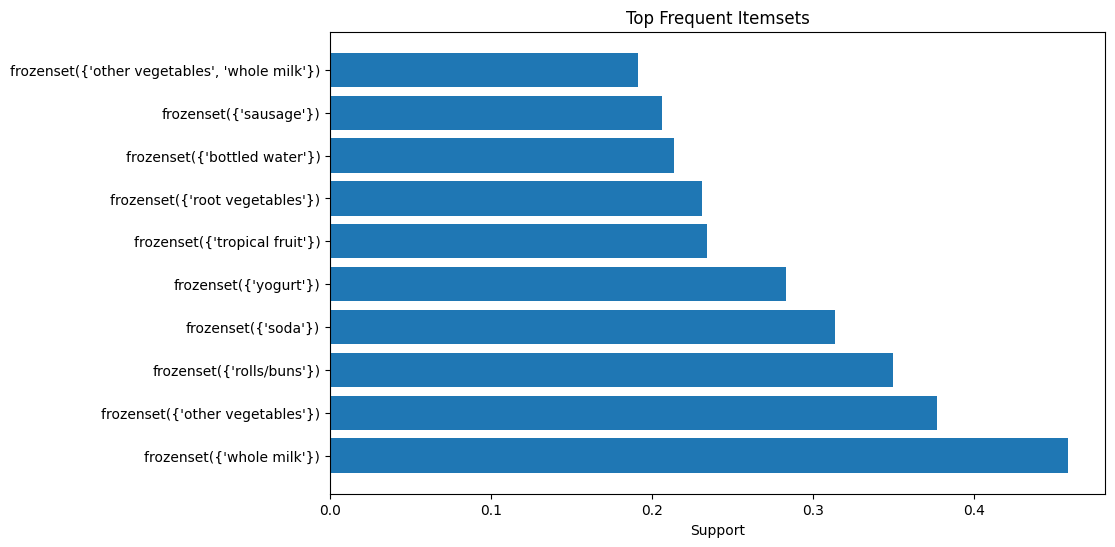

In [10]:
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(range(len(top_items)), top_items['support'])
plt.yticks(range(len(top_items)), top_items['itemsets'])
plt.xlabel("Support")
plt.title("Top Frequent Itemsets")
plt.show()

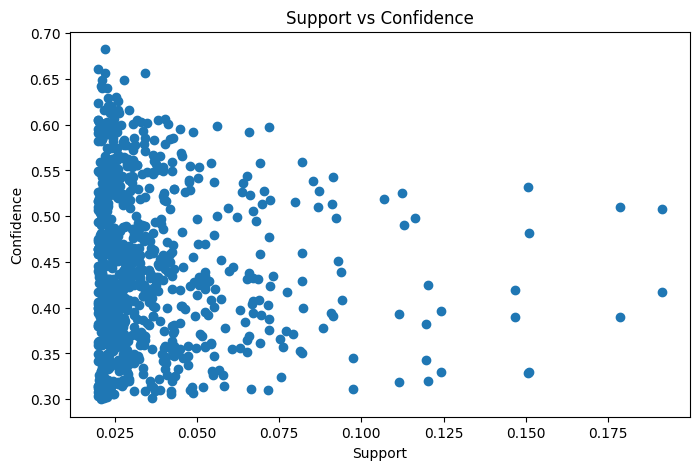

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

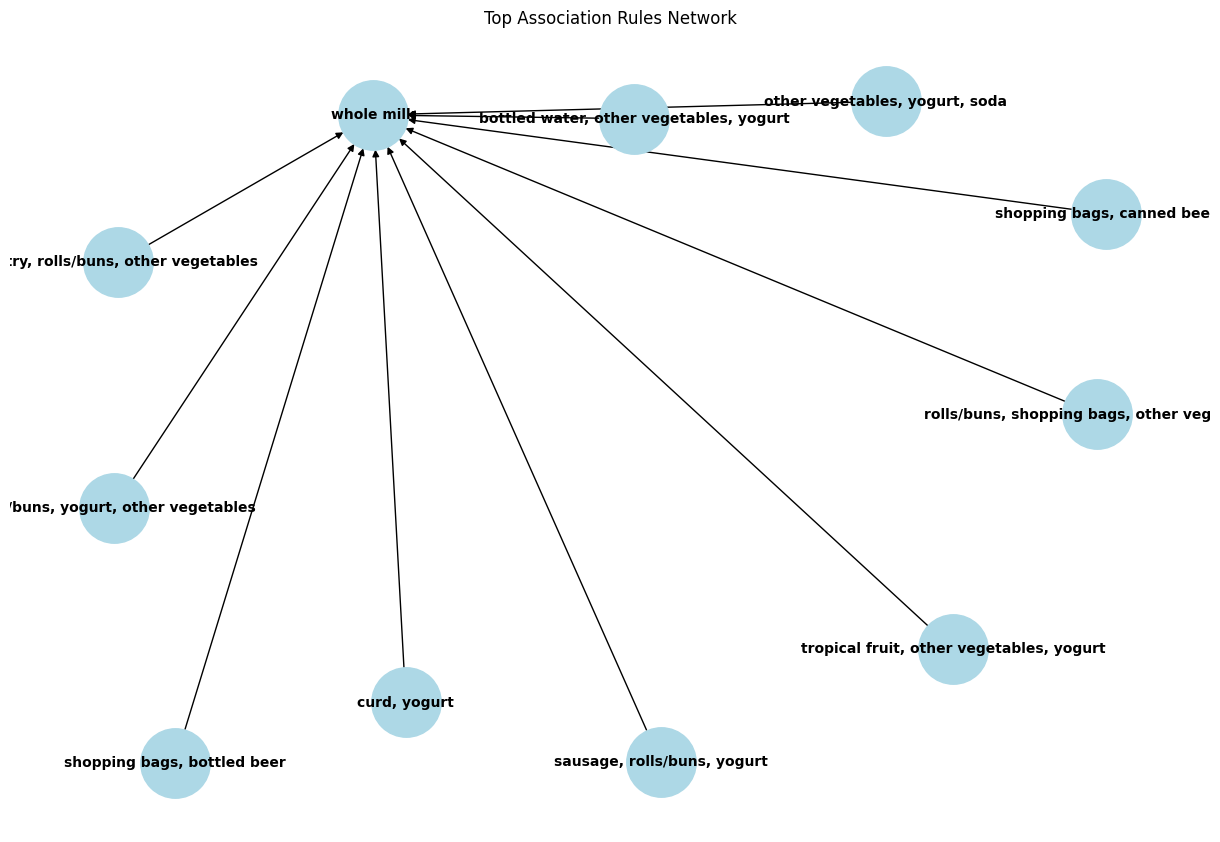

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# Select top rules
top_rules = strong_rules.sort_values(by='confidence', ascending=False).head(10)

G = nx.DiGraph()

for _, row in top_rules.iterrows():
    G.add_edge(
        ', '.join(list(row['antecedents'])),
        ', '.join(list(row['consequents'])),
        weight=row['confidence']
    )

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=1.5)
nx.draw(G, pos,
        with_labels=True,
        node_size=2500,
        node_color='lightblue',
        font_size=10,
        font_weight='bold',
        arrows=True)

plt.title("Top Association Rules Network")
plt.show()

In [13]:
print(rules[['support', 'confidence', 'lift']])

      support  confidence      lift
0    0.038994    0.496732  1.318979
1    0.031042    0.395425  1.130863
2    0.027450    0.349673  1.115406
3    0.040534    0.516340  1.126928
4    0.050795    0.424893  1.128223
..        ...         ...       ...
863  0.022832    0.302721  1.695412
864  0.024628    0.581818  1.269836
865  0.024628    0.373541  1.191540
866  0.024628    0.377953  1.335684
867  0.024628    0.452830  1.295035

[868 rows x 3 columns]


In [14]:
for support in [0.01, 0.02, 0.03]:
    itemsets = apriori(df, min_support=support, use_colnames=True)
    print("Support:", support, "Number of itemsets:", len(itemsets))

Support: 0.01 Number of itemsets: 3016
Support: 0.02 Number of itemsets: 894
Support: 0.03 Number of itemsets: 415


In [15]:
for conf in [0.3, 0.5, 0.7]:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
    print("Confidence:", conf, "Number of rules:", len(rules))

Confidence: 0.3 Number of rules: 868
Confidence: 0.5 Number of rules: 246
Confidence: 0.7 Number of rules: 0


In [16]:
print("Number of rules:", len(rules))
print(rules.head())

Number of rules: 0
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


---
## Scenario - 2

In [17]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [18]:
df.shape

(150, 4)

In [19]:
# Check missing values
print(df.isnull().sum())

# If any missing values exist
df = df.fillna(df.mean())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [21]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Principal Components Shape:", X_pca.shape)

Principal Components Shape: (150, 4)


In [22]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]


In [23]:
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_scaled)

print("Reduced Shape:", X_2d.shape)

Reduced Shape: (150, 2)


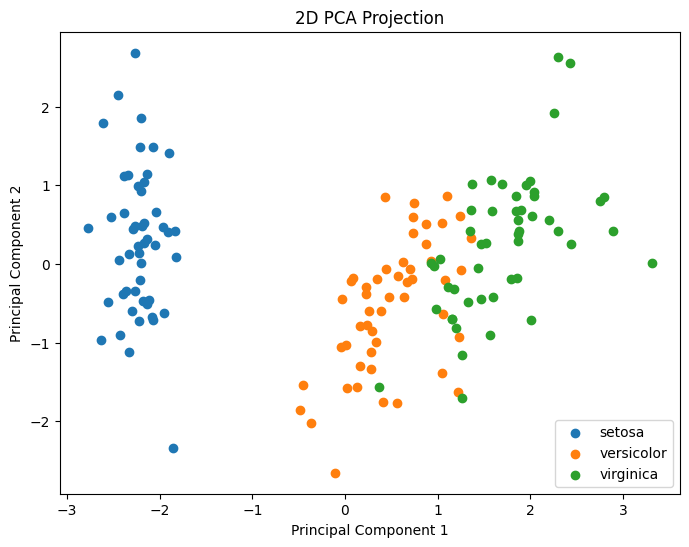

In [24]:
plt.figure(figsize=(8,6))

# Plot each class with label
for i, label in enumerate(iris.target_names):
    plt.scatter(
        X_2d[y == i, 0],
        X_2d[y == i, 1],
        label=label
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection")

plt.legend()
plt.show()

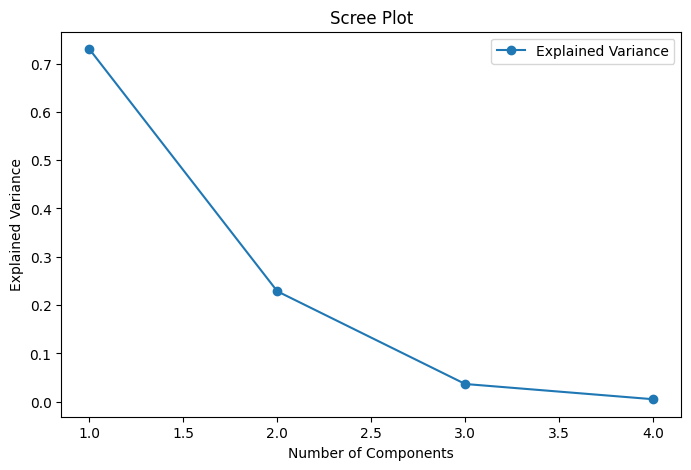

In [25]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         label="Explained Variance")

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")

plt.legend()
plt.show()

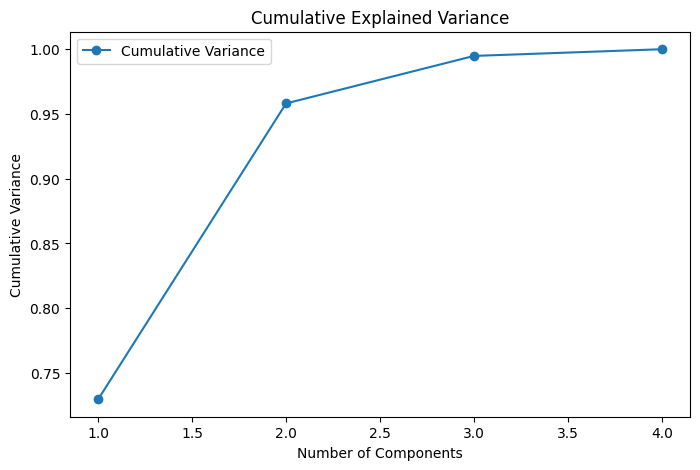

In [26]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o',
         label="Cumulative Variance")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.show()

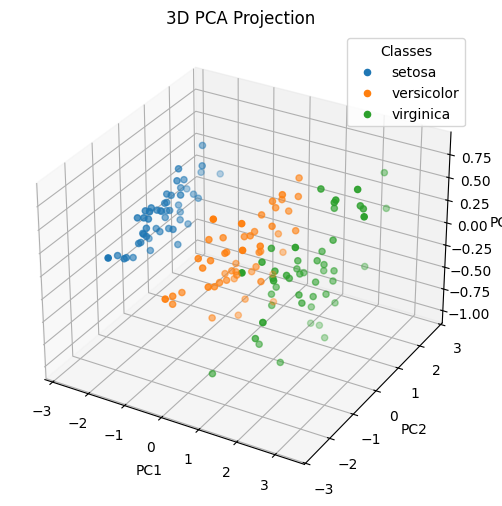

In [27]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Create 3D PCA
pca_3 = PCA(n_components=3)
X_3d = pca_3.fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i, label in enumerate(iris.target_names):
    ax.scatter(
        X_3d[y == i, 0],
        X_3d[y == i, 1],
        X_3d[y == i, 2],
        label=label
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Projection")

ax.legend(title="Classes")
plt.show()